In [49]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

In [2]:
#load dataset
COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak", "slope",
    "ca", "thal", "target"
]

FEATURE_DESCRIPTIONS = {
    "age"     : "Age (years)",
    "sex"     : "Sex (1=male, 0=female)",
    "cp"      : "Chest Pain Type (0–3)",
    "trestbps": "Resting Blood Pressure (mmHg)",
    "chol"    : "Serum Cholesterol (mg/dl)",
    "fbs"     : "Fasting Blood Sugar >120 mg/dl",
    "restecg" : "Resting ECG Results",
    "thalach" : "Max Heart Rate Achieved",
    "exang"   : "Exercise-Induced Angina",
    "oldpeak" : "ST Depression (exercise vs rest)",
    "slope"   : "Slope of Peak Exercise ST Segment",
    "ca"      : "Major Vessels Coloured by Fluoroscopy",
    "thal"    : "Thalassemia (1=normal, 2=fixed, 3=reversible)",
}

In [50]:
print("=" * 62)
print("  HEART DISEASE PREDICTION — SVM CLASSIFIER")
print("=" * 62)

  HEART DISEASE PREDICTION — SVM CLASSIFIER


In [ ]:
try:
    df = pd.read_csv("/home/saka/Downloads/heart_cleveland_upload.csv")
    #standardise column name
    if df.shape[1] == 14:
        df.columns = COLUMNS
    print(f"\n Dataset loaded: {df.shape[0]} rows * {df.shape[1]} cols")
except FileNotFoundError:
    print("\n heart.csv not found — generating synthetic demo data …")
    np.random.seed(42)
    n = 303
    df = pd.DataFrame({
        "age"     : np.random.randint(29, 78, n),
        "sex"     : np.random.randint(0, 2, n),
        "cp"      : np.random.randint(0, 4, n),
        "trestbps": np.random.randint(94, 200, n),
        "chol"    : np.random.randint(126, 565, n),
        "fbs"     : np.random.randint(0, 2, n),
        "restecg" : np.random.randint(0, 3, n),
        "thalach" : np.random.randint(71, 202, n),
        "exang"   : np.random.randint(0, 2, n),
        "oldpeak" : np.round(np.random.uniform(0, 6.2, n), 1),
        "slope"   : np.random.randint(0, 3, n),
        "ca"      : np.random.randint(0, 5, n),
        "thal"    : np.random.randint(0, 4, n),
        "target"  : np.random.randint(0, 2, n),
    })
    print(f" Synthetic dataset ready: {df.shape}")

In [9]:
# target: 1 = disease present, 0 = no disease
df["target"] = (df["target"] > 0).astype(int)

In [10]:
print(f"\n── Class Distribution ──")
vc = df["target"].value_counts()
print(f"  No Disease (0): {vc.get(0,0)}  |  Disease (1): {vc.get(1,0)}")
print(f"  Disease rate  : {vc.get(1,0)/len(df)*100:.1f}%")


── Class Distribution ──
  No Disease (0): 160  |  Disease (1): 137
  Disease rate  : 46.1%


In [11]:
#exploratory data analysis (EDA)
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Heart Disease Dataset — EDA", fontsize=15, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

<Figure size 1600x1000 with 0 Axes>

In [12]:
palette = {0: "#2196F3", 1: "#F44336"}

In [15]:
# target distribution
ax0 = fig.add_subplot(gs[0, 0])
ax0.bar(["No Disease", "Disease"], [vc.get(0,0), vc.get(1,0)],
        color=["#2196F3", "#F44336"], edgecolor="black", width=0.5)
ax0.set_title("Class Distribution"); ax0.set_ylabel("Count")
for i, v in enumerate([vc.get(0,0), vc.get(1,0)]):
    ax0.text(i, v + 2, str(v), ha="center", fontweight="bold")

In [14]:
# age distribution by class
ax1 = fig.add_subplot(gs[0, 1])
for cls, color in palette.items():
    subset = df[df["target"] == cls]["age"]
    ax1.hist(subset, bins=20, alpha=0.6, color=color,
             label=["No Disease", "Disease"][cls], edgecolor="white")
ax1.set_title("Age Distribution by Class")
ax1.set_xlabel("Age"); ax1.legend()


In [16]:
# max HR by class
ax2 = fig.add_subplot(gs[0, 2])
df.boxplot(column="thalach", by="target", ax=ax2,
           boxprops=dict(color="black"),
           medianprops=dict(color="crimson", linewidth=2))
ax2.set_title("Max Heart Rate by Class")
ax2.set_xlabel("Class (0=Healthy, 1=Disease)")
ax2.set_ylabel("Max HR (bpm)")
plt.sca(ax2); plt.title("Max Heart Rate by Class")

Text(0.5, 1.0, 'Max Heart Rate by Class')

In [17]:
# chest pain type
ax3 = fig.add_subplot(gs[1, 0])
cp_counts = df.groupby(["cp", "target"]).size().unstack(fill_value=0)
cp_counts.plot(kind="bar", ax=ax3, color=["#2196F3", "#F44336"],
               edgecolor="black", width=0.6)
ax3.set_title("Chest Pain Type vs Disease"); ax3.set_xlabel("CP Type")
ax3.legend(["No Disease", "Disease"]); ax3.tick_params(axis='x', rotation=0)

In [18]:
# cholesterol scatter
ax4 = fig.add_subplot(gs[1, 1])
for cls, color in palette.items():
    sub = df[df["target"] == cls]
    ax4.scatter(sub["age"], sub["chol"], c=color, alpha=0.4, s=20,
                label=["No Disease", "Disease"][cls])
ax4.set_title("Age vs Cholesterol"); ax4.set_xlabel("Age")
ax4.set_ylabel("Cholesterol"); ax4.legend()

In [19]:
# correlation heatmap
ax5 = fig.add_subplot(gs[1, 2])
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax5, mask=mask, cmap="coolwarm", center=0,
            linewidths=0.3, annot=False, square=True)
ax5.set_title("Feature Correlation")

Text(0.5, 1.0, 'Feature Correlation')

In [20]:
plt.savefig("eda_heart.png", dpi=130, bbox_inches="tight")
print("\n EDA saved → eda_heart.png")


 EDA saved → eda_heart.png


In [21]:
# pre-processing
X = df.drop("target", axis=1)
y = df["target"]

In [22]:
# handle missing values
X = X.fillna(X.median())

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n Train: {len(X_train)} | Test: {len(X_test)}")


 Train: 237 | Test: 60


In [24]:
# SVM - Pipeline
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC(kernel="rbf", probability=True, random_state=42))
])

In [28]:
# hyperparameter tuning - GridSearchCV
print("\n Hyperparameter Tuning (GridSearchCV, 5-fold CV) ")
param_grid = {
    "svm__C"    : [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto", 0.01, 0.001],
    "svm__kernel": ["rbf", "linear"],
}


 Hyperparameter Tuning (GridSearchCV, 5-fold CV) 


In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    svm_pipeline, param_grid,
    cv=cv, scoring="roc_auc",
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 'auto', ...], 'svm__kernel': ['rbf', 'linear']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [30]:
best_model = grid_search.best_estimator_
print(f"  Best params : {grid_search.best_params_}")
print(f"  Best CV AUC : {grid_search.best_score_:.4f}")

  Best params : {'svm__C': 1, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
  Best CV AUC : 0.8996


In [31]:
# model evaluation
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [32]:
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)

In [34]:
print(f"\n Test Set Results ")
print(f"  ROC-AUC : {roc_auc:.4f}")
print(f"  PR-AUC  : {pr_auc:.4f}")
print(f"\n{classification_report(y_test, y_pred, target_names=['No Disease','Disease'])}")


 Test Set Results 
  ROC-AUC : 0.9241
  PR-AUC  : 0.9402

              precision    recall  f1-score   support

  No Disease       0.78      1.00      0.88        32
     Disease       1.00      0.68      0.81        28

    accuracy                           0.85        60
   macro avg       0.89      0.84      0.84        60
weighted avg       0.88      0.85      0.84        60



In [35]:
# cross-validation scores
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring="roc_auc")
print(f"  5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

  5-Fold CV AUC: 0.9068 ± 0.0442


Text(0.5, 0.98, 'SVM — Model Evaluation (Heart Disease)')

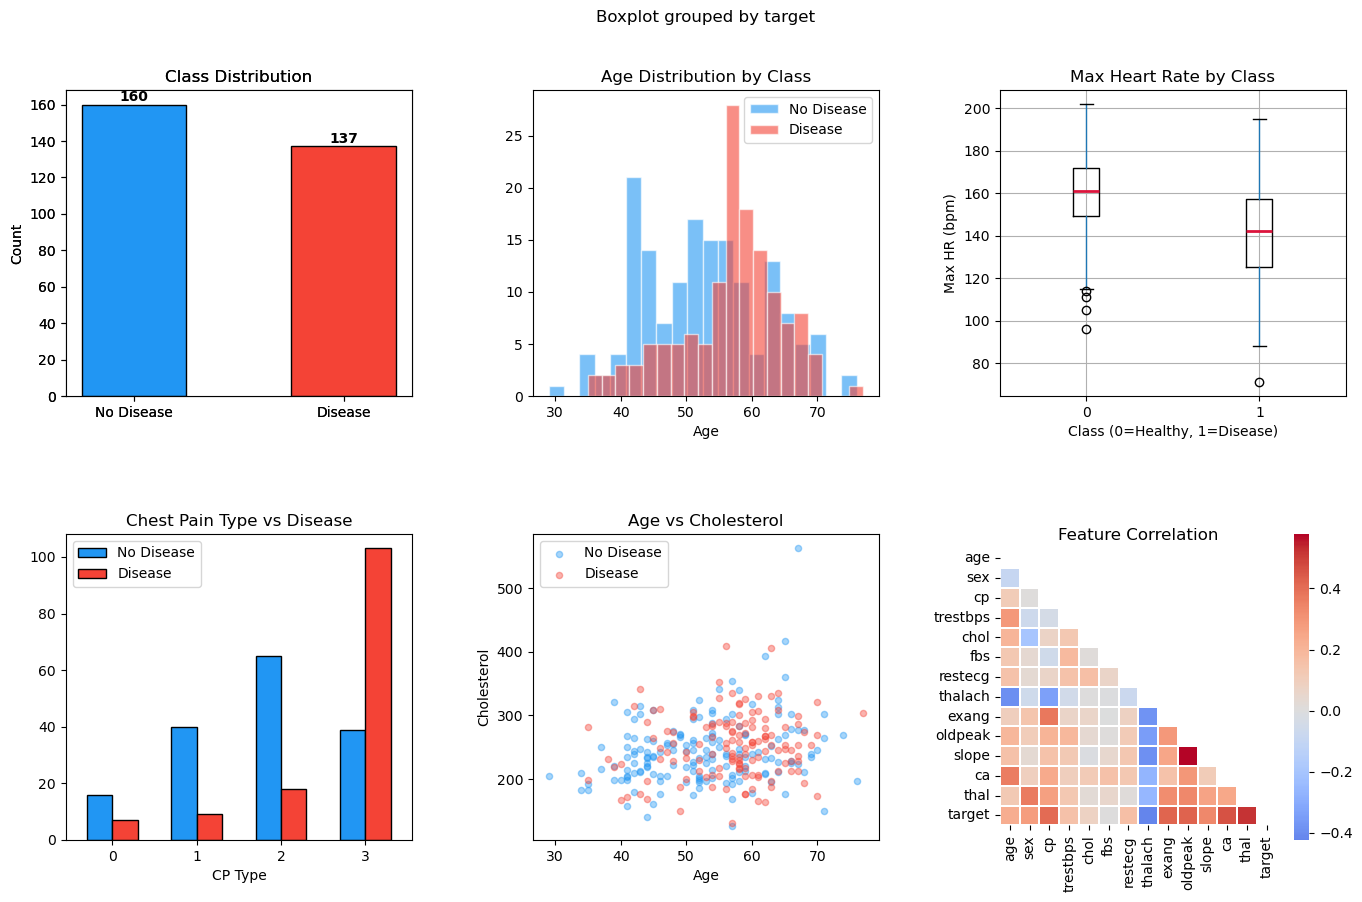

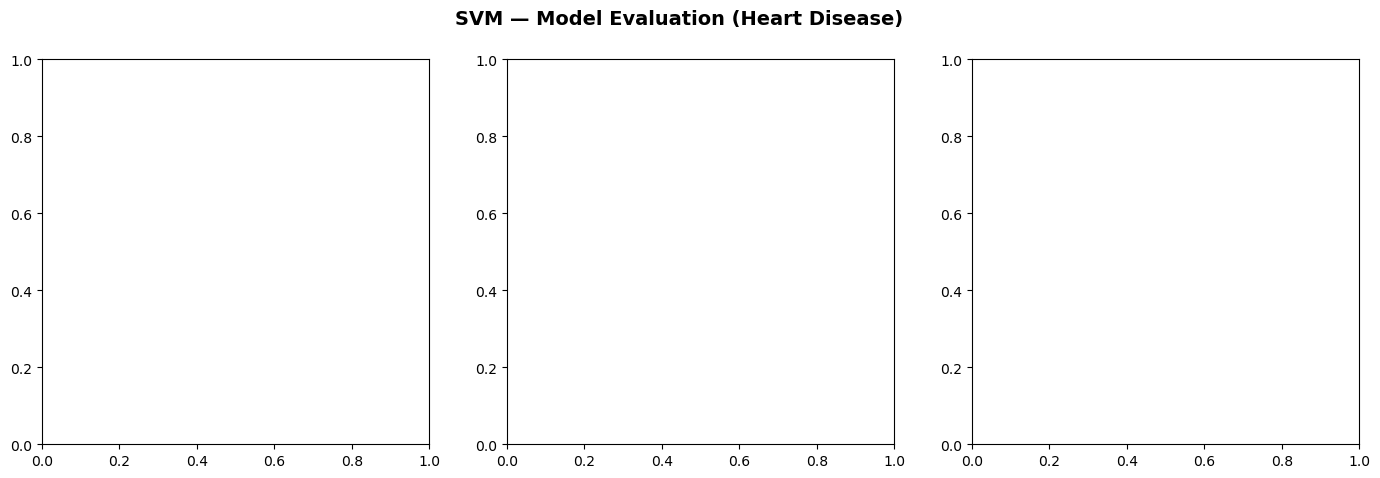

In [36]:
# evaluation plots
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("SVM — Model Evaluation (Heart Disease)", fontsize=14, fontweight="bold")

In [37]:
# confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

Text(0.5, 1.0, 'Confusion Matrix')

In [38]:
# Receiver Operating Characteristic (ROC) Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#F44336", lw=2, label=f"SVM (AUC={roc_auc:.3f})")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#F44336")
axes[1].plot([0,1],[0,1],"k--", lw=1)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend()

In [39]:
# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec, color="#2196F3", lw=2, label=f"SVM (AP={pr_auc:.3f})")
axes[2].fill_between(rec, prec, alpha=0.1, color="#2196F3")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve"); axes[2].legend()

In [48]:
plt.tight_layout()
plt.savefig("svm_evaluation.png", dpi=130, bbox_inches="tight")
print("\n Evaluation plots saved → svm_evaluation.png")


 Evaluation plots saved → svm_evaluation.png


<Figure size 640x480 with 0 Axes>

# permutation feature importance
print("\n Permutation Feature Importance ")
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=30, random_state=42, scoring="roc_auc"
)
feat_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=True)

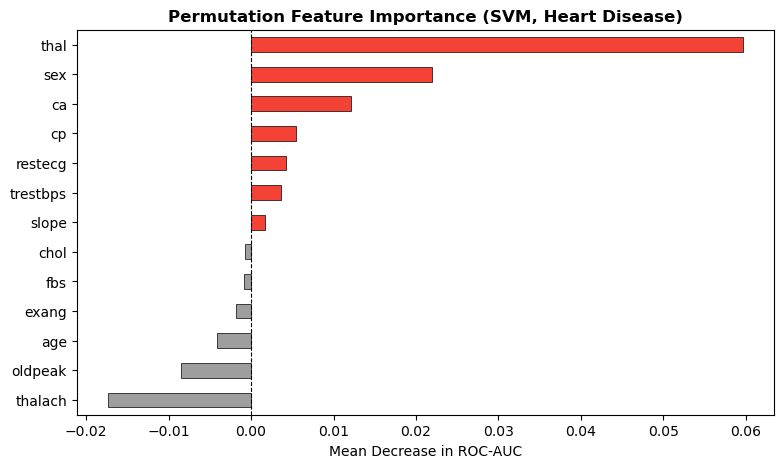

In [43]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#F44336" if v > 0 else "#9E9E9E" for v in feat_imp.values]
feat_imp.plot(kind="barh", ax=ax, color=colors, edgecolor="black", linewidth=0.5)
ax.set_title("Permutation Feature Importance (SVM, Heart Disease)", fontweight="bold")
ax.set_xlabel("Mean Decrease in ROC-AUC")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

In [47]:
# Add feature descriptions
labels = [FEATURE_DESCRIPTIONS.get(n, n) for n in feat_imp.index]
ax.set_yticklabels(labels, fontsize=8)
plt.tight_layout()
plt.savefig("feature_importance_svm.png", dpi=130, bbox_inches="tight")
print(" Feature importance saved → feature_importance_svm.png")


 Feature importance saved → feature_importance_svm.png


<Figure size 640x480 with 0 Axes>